In [1]:
import os
import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display, clear_output

os.environ["TOKENIZERS_PARALLELISM"] = "false"
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

device = "cpu"
dtype = torch.float32

c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


In [2]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False,
).to(device)

pipe.enable_attention_slicing()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\jacob\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
BASE_STYLE = "stylized animated film, soft lighting, clean shapes, cinematic composition"
NEGATIVE = "photorealistic, hyper-detailed, blurry, distorted, text, watermark"

CHAR_ANCHOR = (
    "same little girl in every scene: 8 year old girl, short brown bob haircut, "
    "yellow raincoat, blue rain boots, freckles, round face"
)

scene_prompts = [
    f"{CHAR_ANCHOR}. wide shot, walking alone across empty field. {BASE_STYLE}",
    f"{CHAR_ANCHOR}. medium shot, kneeling to examine a small flower in grass. {BASE_STYLE}",
    f"{CHAR_ANCHOR}. close shot, smiling gently while holding the flower. {BASE_STYLE}",
    f"{CHAR_ANCHOR}. side profile, walking with flower tucked in coat pocket. {BASE_STYLE}",
]

  0%|          | 0/10 [00:00<?, ?it/s]

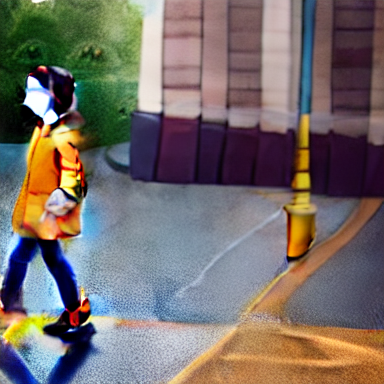

In [5]:
WIDTH, HEIGHT = 384, 384
STEPS = 10
GUIDANCE = 6.0

generated_images = []

for i, prompt in enumerate(scene_prompts, 1):
    clear_output(wait=True)

    img = pipe(
        prompt=prompt,
        negative_prompt=NEGATIVE,
        width=WIDTH,
        height=HEIGHT,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        generator=torch.Generator(device=device).manual_seed(100 + i),
    ).images[0]

    generated_images.append(img)
    display(img)

In [6]:
import os

output_dir = os.path.join(os.getcwd(), "girl_storyboard")
os.makedirs(output_dir, exist_ok=True)

for i, img in enumerate(generated_images, 1):
    img.save(os.path.join(output_dir, f"scene_{i}.png"))

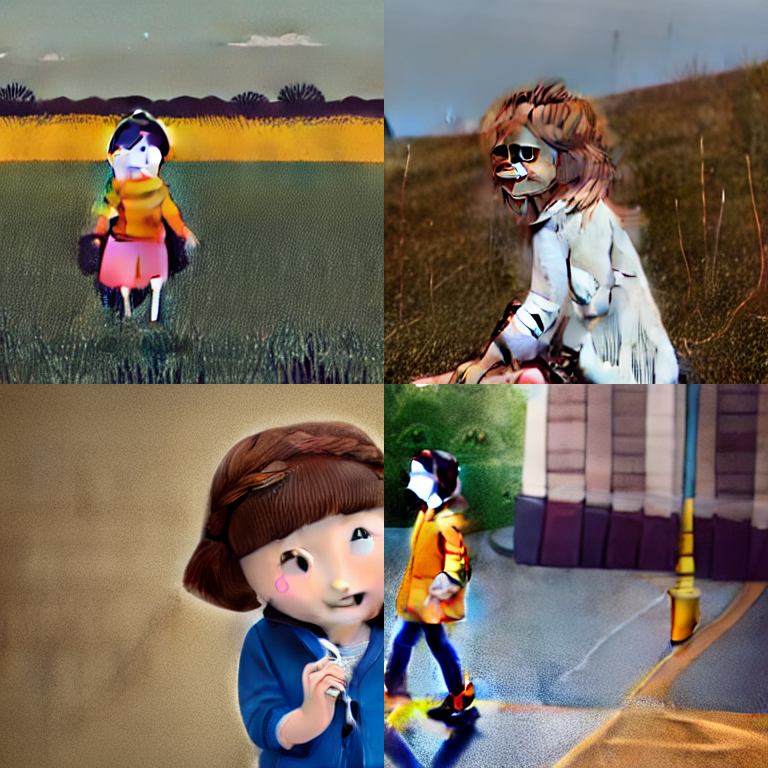

In [7]:
from PIL import Image

WIDTH, HEIGHT = generated_images[0].size

storyboard = Image.new("RGB", (WIDTH * 2, HEIGHT * 2))

storyboard.paste(generated_images[0], (0, 0))
storyboard.paste(generated_images[1], (WIDTH, 0))
storyboard.paste(generated_images[2], (0, HEIGHT))
storyboard.paste(generated_images[3], (WIDTH, HEIGHT))

display(storyboard)